In [2]:

# REQUIRED LIBRARIES FOR THE RETAIL CUSTOMER SEGMENTATION  PROJECT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# For Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# for Set styling
sns.set_style("whitegrid")
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# ============================================
# DATA GENERATION (Alheri Supermarket - 2025-2026)
# Fixed: only bulk purchases when both bulk_qty and bulk_price exist
# ============================================

import random
np.random.seed(42)
random.seed(42)

# ---------------------------
# Product Catalog (from market data) – same as before
# ---------------------------
products = [
    # Fresh Produce & Staples
    {'category': 'Foodstuff', 'product': 'Rice (50kg bag)', 'unit_price': 61000, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Foodstuff', 'product': 'Rice (1kg)', 'unit_price': 2200, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Foodstuff', 'product': 'Beans (paint bucket)', 'unit_price': 2700, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Foodstuff', 'product': 'Garri (paint bucket)', 'unit_price': 1900, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Foodstuff', 'product': 'Yam (medium tuber)', 'unit_price': 3200, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Foodstuff', 'product': 'Tomatoes (1kg)', 'unit_price': 1300, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Foodstuff', 'product': 'Onions (1kg)', 'unit_price': 1300, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Foodstuff', 'product': 'Beef (1kg)', 'unit_price': 8500, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Foodstuff', 'product': 'Frozen Chicken (1kg)', 'unit_price': 5800, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Foodstuff', 'product': 'Eggs (crate of 30)', 'unit_price': 6800, 'bulk_price': None, 'bulk_qty': None},

    # Pantry & Packaged
    {'category': 'Beverages', 'product': 'Bread (500g loaf)', 'unit_price': 800, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Beverages', 'product': 'Cowbell Vitarich Cream (12g sachet)', 'unit_price': 200, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Beverages', 'product': 'Golden Morn (45g sachet)', 'unit_price': 400, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Beverages', 'product': 'Milk (1 litre)', 'unit_price': 2022, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Beverages', 'product': 'Spaghetti (carton of 12 packs)', 'unit_price': 18500, 'bulk_price': 770, 'bulk_qty': 12},
    {'category': 'Beverages', 'product': 'Indomie (carton of 24 packs)', 'unit_price': 9800, 'bulk_price': 408, 'bulk_qty': 24},

    # Cooking & Condiments
    {'category': 'Household', 'product': 'Palm Oil (75cl bottle)', 'unit_price': 2200, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Household', 'product': 'Terra Oil (1 litre)', 'unit_price': 3300, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Household', 'product': 'Maggi Star Cube (4g x 20s)', 'unit_price': 40, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Household', 'product': 'Tomato Paste (one roll)', 'unit_price': 1200, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Household', 'product': 'Salt (big size)', 'unit_price': 450, 'bulk_price': None, 'bulk_qty': None},

    # Frozen
    {'category': 'Foodstuff', 'product': 'Frozen Chicken Laps', 'unit_price': 2000, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Foodstuff', 'product': 'Frozen Titus Fish (1kg)', 'unit_price': 7000, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Foodstuff', 'product': 'Frozen Mackerel (1kg)', 'unit_price': 6800, 'bulk_price': None, 'bulk_qty': None},

    # Wine, Spirits & Deli
    {'category': 'Beverages', 'product': 'Domestic Beer (0.5L bottle)', 'unit_price': 1500, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Beverages', 'product': 'Red Table Wine (good quality)', 'unit_price': 9000, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Beverages', 'product': 'Coca-Cola (2L bottle)', 'unit_price': 2207, 'bulk_price': None, 'bulk_qty': None},

    # Household
    {'category': 'Household', 'product': 'Laundry Detergent (3L)', 'unit_price': 8477, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Household', 'product': 'Bar Soap', 'unit_price': 229, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Household', 'product': 'Toothpaste', 'unit_price': 3500, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Household', 'product': 'Baby Diapers (bulk 92 pcs)', 'unit_price': 100000, 'bulk_price': 1087, 'bulk_qty': 92},

    # Electronics/Phone
    {'category': 'Electronics', 'product': 'Phone Charger', 'unit_price': 6500, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Electronics', 'product': 'Power Bank', 'unit_price': 15000, 'bulk_price': None, 'bulk_qty': None},

    # Clothing
    {'category': 'Clothing', 'product': "Men's T-shirt", 'unit_price': 2500, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Clothing', 'product': "Women's Dress", 'unit_price': 7000, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Clothing', 'product': 'Jeans', 'unit_price': 5000, 'bulk_price': None, 'bulk_qty': None},

    # Phone Accessories
    {'category': 'Phone Accessories', 'product': 'Screen Protector', 'unit_price': 1500, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Phone Accessories', 'product': 'Phone Case', 'unit_price': 2000, 'bulk_price': None, 'bulk_qty': None},

    # Baby Items
    {'category': 'Baby Items', 'product': 'Baby Wipes', 'unit_price': 1200, 'bulk_price': None, 'bulk_qty': None},
    {'category': 'Baby Items', 'product': 'Baby Formula (400g)', 'unit_price': 8000, 'bulk_price': None, 'bulk_qty': None},
]

# Add product IDs
for idx, p in enumerate(products):
    p['product_id'] = idx + 1

products_df = pd.DataFrame(products)

# ---------------------------
# Generate Transactions (Fixed)
# ---------------------------
def generate_transactions(start_date='2025-01-01', end_date='2026-06-30',
                          avg_customers_per_day=600, n_customers=2500):

    start = datetime.strptime(start_date, '%Y-%m-%d')
    end = datetime.strptime(end_date, '%Y-%m-%d')
    days = (end - start).days + 1

    customer_ids = list(range(1001, 1001 + n_customers))
    activity_levels = np.random.exponential(scale=2, size=n_customers)
    activity_levels = np.clip(activity_levels, 0.2, 6)

    all_transactions = []
    products_by_category = products_df.groupby('category')['product_id'].apply(list).to_dict()

    category_weights = {
        'Foodstuff': 0.40,
        'Beverages': 0.25,
        'Household': 0.15,
        'Electronics': 0.05,
        'Clothing': 0.05,
        'Phone Accessories': 0.05,
        'Baby Items': 0.05,
    }

    for day in range(days):
        current_date = start + timedelta(days=day)
        n_today = max(1, np.random.poisson(avg_customers_per_day))
        probs = np.array(activity_levels) / 30
        probs = np.clip(probs, 0.01, 0.9)
        chosen = np.random.choice(customer_ids, size=n_today, p=probs/probs.sum(), replace=True)

        for cust_id in chosen:
            n_items = np.random.randint(1, 6)
            categories = list(category_weights.keys())
            weights = list(category_weights.values())
            selected_cats = np.random.choice(categories, size=n_items, p=weights)

            for cat in selected_cats:
                prod_id = np.random.choice(products_by_category[cat])
                product_row = products_df[products_df['product_id'] == prod_id].iloc[0]

                # ✅ FIX: only bulk if both bulk_qty and bulk_price are not None
                is_bulk = False
                if (product_row['bulk_qty'] is not None and
                    product_row['bulk_price'] is not None and
                    np.random.random() < 0.3):
                    is_bulk = True
                    quantity = product_row['bulk_qty']
                    unit_price = product_row['bulk_price']
                else:
                    quantity = np.random.randint(1, 5)
                    if 'Eggs' in product_row['product']:
                        quantity = np.random.choice([6, 12, 30])
                    elif 'Rice (50kg)' in product_row['product']:
                        quantity = 1
                    else:
                        quantity = np.random.randint(1, 5)
                    unit_price = product_row['unit_price']

                total = quantity * unit_price
                all_transactions.append({
                    'CustomerID': cust_id,
                    'InvoiceDate': current_date,
                    'ProductID': prod_id,
                    'ProductName': product_row['product'],
                    'Category': product_row['category'],
                    'Quantity': quantity,
                    'UnitPrice': unit_price,
                    'TotalPrice': total,
                    'IsBulk': is_bulk
                })

    return pd.DataFrame(all_transactions)

# Generate data with correct date range
df = generate_transactions(start_date='2025-01-01', end_date='2026-06-30')
df.to_csv('retail_transactions.csv', index=False)

print(f"\n✅ Generated {len(df):,} transactions")
print(f"   Unique customers: {df['CustomerID'].nunique():,}")
print(f"   Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"   Total revenue: ₦{df['TotalPrice'].sum():,.2f}")
print(f"   Bulk purchases: {df['IsBulk'].sum():,} ({df['IsBulk'].sum()/len(df)*100:.1f}%)")

# Check for NaN values
print(f"\nNaN check:")
print(df.isnull().sum())

# Optionally drop any rows with NaN (should be none now)
df.dropna(inplace=True)

print("\nSample transactions:")
df.head(10)


✅ Generated 986,220 transactions
   Unique customers: 2,500
   Date range: 2025-01-01 00:00:00 to 2026-06-30 00:00:00
   Total revenue: ₦15,856,321,170.00
   Bulk purchases: 296,741 (30.1%)

NaN check:
CustomerID          0
InvoiceDate         0
ProductID           0
ProductName         0
Category            0
Quantity       275130
UnitPrice      275130
TotalPrice     275130
IsBulk              0
dtype: int64

Sample transactions:


,CustomerID,InvoiceDate,ProductID,ProductName,Category,Quantity,UnitPrice,TotalPrice,IsBulk
3,3390,2025-01-01,10,Eggs (crate of 30),Foodstuff,12.0,6800.0,81600.0,False
4,1494,2025-01-01,16,Indomie (carton of 24 packs),Beverages,4.0,9800.0,39200.0,False
5,1494,2025-01-01,22,Frozen Chicken Laps,Foodstuff,2.0,2000.0,4000.0,False
6,1494,2025-01-01,22,Frozen Chicken Laps,Foodstuff,2.0,2000.0,4000.0,False
7,1272,2025-01-01,16,Indomie (carton of 24 packs),Beverages,1.0,9800.0,9800.0,False
8,1272,2025-01-01,24,Frozen Mackerel (1kg),Foodstuff,3.0,6800.0,20400.0,False
10,1272,2025-01-01,11,Bread (500g loaf),Beverages,2.0,800.0,1600.0,False
11,3125,2025-01-01,15,Spaghetti (carton of 12 packs),Beverages,12.0,770.0,9240.0,True
12,3125,2025-01-01,37,Screen Protector,Phone Accessories,1.0,1500.0,1500.0,False
15,3110,2025-01-01,10,Eggs (crate of 30),Foodstuff,6.0,6800.0,40800.0,False


=== DATA OVERVIEW ===
Total transactions: 711,090
Total customers: 2,500
Total products: 40
Total revenue: ₦15,856,321,170.00
Average transaction value: ₦22298.61
Bulk purchases: 21,611 (3.0%)

=== CATEGORY ANALYSIS ===
                   Total Revenue  Avg Transaction  Transactions  \
Category                                                          
Foodstuff           7.786587e+09         28235.49        275773   
Household           3.893321e+09         35962.69        108260   
Beverages           2.283712e+09         12093.11        188844   
Electronics         9.263305e+08         26900.84         34435   
Clothing            4.148315e+08         12046.10         34437   
Baby Items          4.009332e+08         11487.40         34902   
Phone Accessories   1.506060e+08          4373.12         34439   

                   Unique Customers  
Category                             
Foodstuff                      2500  
Household                      2498  
Beverages               

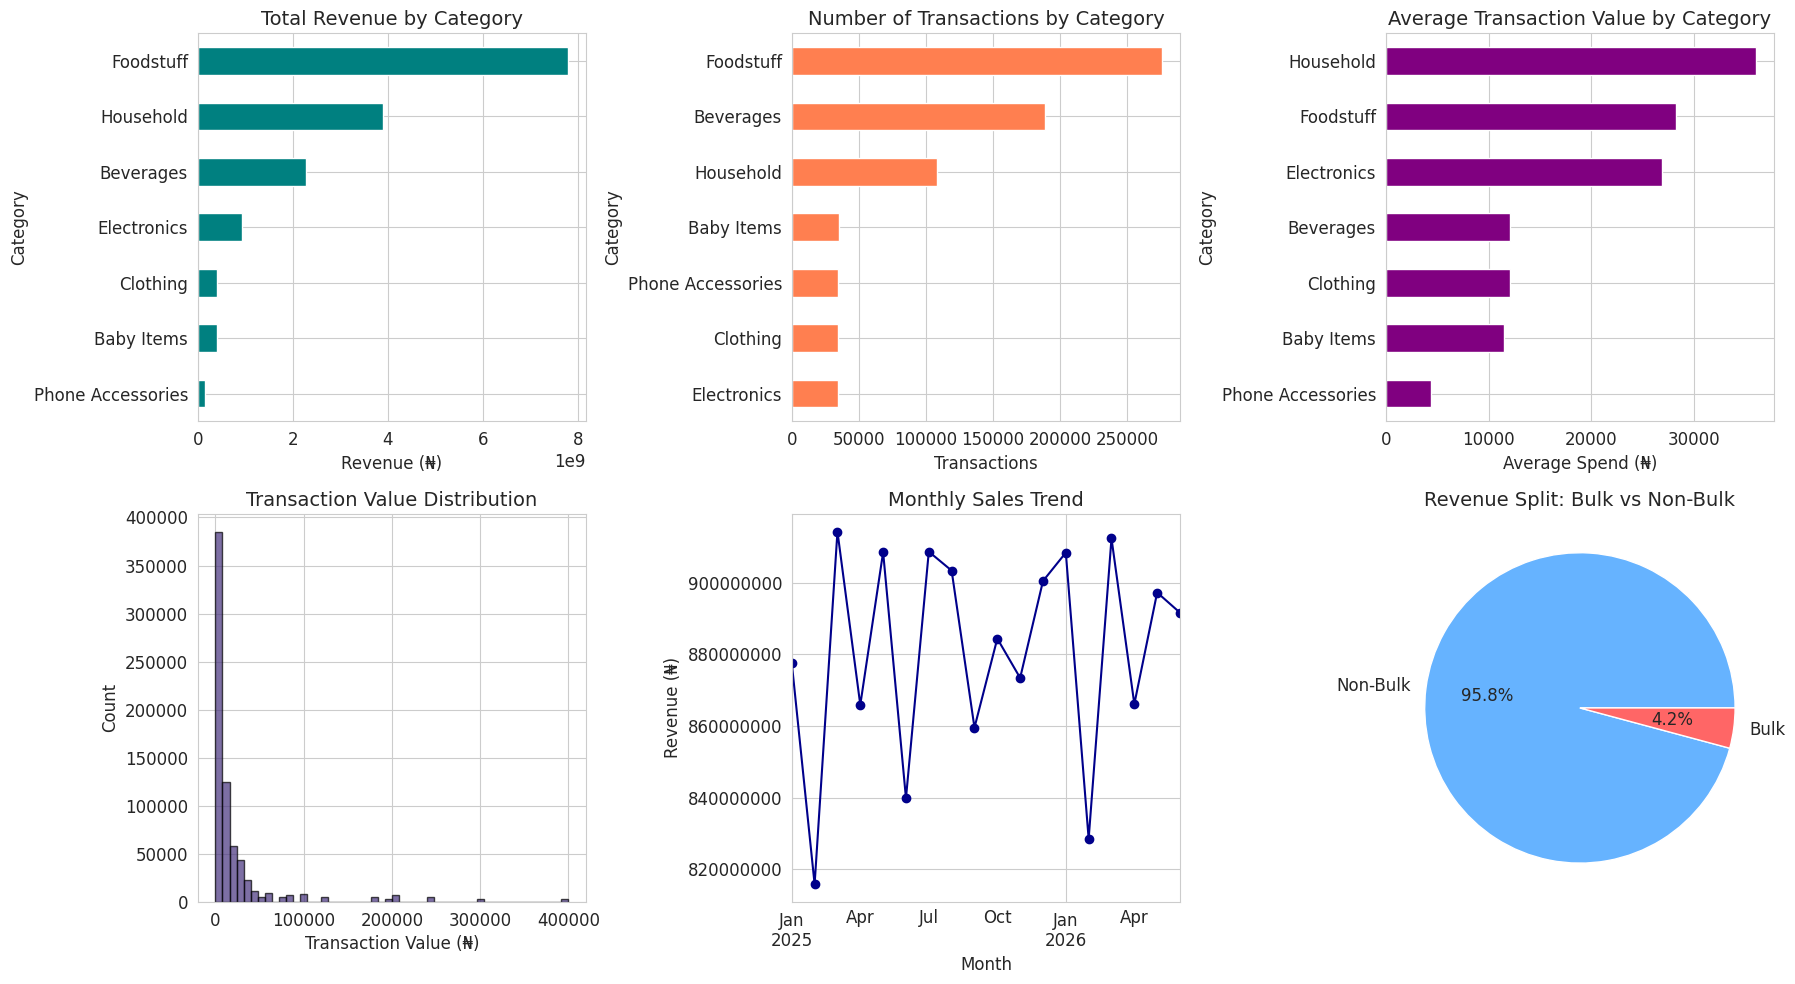

✅ EDA visualizations saved!


In [4]:

# EXPLORATORY DATA ANALYSIS (EDA)

print("=== DATA OVERVIEW ===")
print(f"Total transactions: {len(df):,}")
print(f"Total customers: {df['CustomerID'].nunique():,}")
print(f"Total products: {df['ProductID'].nunique():,}")
print(f"Total revenue: ₦{df['TotalPrice'].sum():,.2f}")
print(f"Average transaction value: ₦{df['TotalPrice'].mean():.2f}")
print(f"Bulk purchases: {df['IsBulk'].sum():,} ({df['IsBulk'].sum()/len(df)*100:.1f}%)")

# Category analysis
print("\n=== CATEGORY ANALYSIS ===")
category_stats = df.groupby('Category').agg({
    'TotalPrice': ['sum', 'mean', 'count'],
    'CustomerID': 'nunique'
}).round(2)
category_stats.columns = ['Total Revenue', 'Avg Transaction', 'Transactions', 'Unique Customers']
print(category_stats.sort_values('Total Revenue', ascending=False))

# Enhanced Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Revenue by Category (barh)
cat_rev = df.groupby('Category')['TotalPrice'].sum().sort_values(ascending=True)
cat_rev.plot(kind='barh', ax=axes[0,0], color='teal')
axes[0,0].set_title('Total Revenue by Category', fontsize=14)
axes[0,0].set_xlabel('Revenue (₦)')

# 2. Transaction Count by Category
cat_count = df.groupby('Category').size().sort_values(ascending=True)
cat_count.plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Number of Transactions by Category', fontsize=14)
axes[0,1].set_xlabel('Transactions')

# 3. Average Transaction Value by Category
cat_avg = df.groupby('Category')['TotalPrice'].mean().sort_values(ascending=True)
cat_avg.plot(kind='barh', ax=axes[0,2], color='purple')
axes[0,2].set_title('Average Transaction Value by Category', fontsize=14)
axes[0,2].set_xlabel('Average Spend (₦)')

# 4. Transaction Value Distribution
axes[1,0].hist(df['TotalPrice'], bins=50, edgecolor='black', alpha=0.7)
axes[1,0].set_title('Transaction Value Distribution', fontsize=14)
axes[1,0].set_xlabel('Transaction Value (₦)')
axes[1,0].set_ylabel('Count')
axes[1,0].ticklabel_format(style='plain', axis='x')

# 5. Monthly Sales Trend
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
monthly_sales.plot(kind='line', marker='o', ax=axes[1,1], color='darkblue')
axes[1,1].set_title('Monthly Sales Trend', fontsize=14)
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Revenue (₦)')
axes[1,1].ticklabel_format(style='plain', axis='y')

# 6. Bulk vs Non-Bulk Revenue
bulk_rev = df.groupby('IsBulk')['TotalPrice'].sum()
bulk_rev.index = ['Non-Bulk', 'Bulk']
bulk_rev.plot(kind='pie', ax=axes[1,2], autopct='%1.1f%%', colors=['#66b3ff', '#ff6666'])
axes[1,2].set_title('Revenue Split: Bulk vs Non-Bulk', fontsize=14)
axes[1,2].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ EDA visualizations saved!")

In [5]:
# ============================================
# RFM ANALYSIS + PRODUCT PREFERENCES
# ============================================

snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)

# Per-customer RFM metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'CustomerID': 'count',                                    # Frequency
    'TotalPrice': 'sum',                                      # Monetary
    'Quantity': 'sum',                                        # Total items
    'IsBulk': 'sum',                                          # Bulk count
    'Category': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
    'ProductName': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'CustomerID': 'Frequency',
    'TotalPrice': 'Monetary',
    'Quantity': 'TotalItems',
    'IsBulk': 'BulkCount',
    'Category': 'PreferredCategory',
    'ProductName': 'PreferredProduct'
})

# Add average basket size
rfm['AvgBasketSize'] = rfm['TotalItems'] / rfm['Frequency']
rfm['BulkRatio'] = rfm['BulkCount'] / rfm['Frequency']  # fraction of bulk purchases

print("=== RFM METRICS ===")
print(f"Customers analyzed: {len(rfm):,}")
print(f"Average Recency: {rfm['Recency'].mean():.1f} days")
print(f"Average Frequency: {rfm['Frequency'].mean():.1f} purchases")
print(f"Average Monetary: ₦{rfm['Monetary'].mean():,.2f}")
print(f"Average Basket Size: {rfm['AvgBasketSize'].mean():.1f} items")

# RFM Scores (1-5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("\nRFM Score Distribution (Top 10):")
print(rfm['RFM_Score'].value_counts().head(10))

=== RFM METRICS ===
Customers analyzed: 2,500
Average Recency: 10.5 days
Average Frequency: 284.4 purchases
Average Monetary: ₦6,342,528.47
Average Basket Size: 3.9 items

RFM Score Distribution (Top 10):
RFM_Score
111    243
555    201
455    183
444    136
233    120
544    119
222    116
122    101
211    100
333     98
Name: count, dtype: int64


In [8]:
# ============================================
# FEATURE ENGINEERING FOR CLUSTERING
# ============================================

# Log-transform Monetary to handle skew
rfm['Log_Monetary'] = np.log1p(rfm['Monetary'])

# We'll use Recency, Frequency, Log_Monetary (standard RFM)
# but can also include AvgBasketSize and BulkRatio for extra insight
features = ['Recency', 'Frequency', 'Log_Monetary']
X = rfm[features].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled. Shape:", X_scaled.shape)

Features scaled. Shape: (2500, 3)
